In [1]:
import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

from nbtools import auto_plot_style

%matplotlib inline
auto_plot_style()

In [3]:
filename     = "/home/gonzalo/sw/git/sentinel/pcolina_trajectories_center.txt"
filename     = "/home/gonzalo/sw/git/sentinel/deleteme.txt"
filename     = "/home/gonzalo/sw/git/sentinel/pcolina_trajectories_cathode.txt"
filename     = "/home/gonzalo/sw/git/sentinel/pcolina_trajectories_volume2.txt"
filename     = "/home/gonzalo/sw/git/sentinel/pcolina_trajectories_volume3.txt"
filename     = "/home/gonzalo/sw/git/sentinel/trajectories.csv"
trajectories = pd.read_csv( filename
                          , sep="\s+"
                          , skiprows=1
                          , names="evt x y z t".split())

In [4]:
trajectories.describe()

,evt,x,y,z,t
count,8.626401e+06,8.626401e+06,8.626401e+06,8.626401e+06,8.626401e+06
mean,4.973457e+02,-3.282766e-01,1.302811e+00,7.902438e+01,6.886138e+01
std,2.840532e+02,4.727485e+01,4.743940e+01,3.614450e+01,6.418970e+01
min,0.000000e+00,-1.338737e+02,-1.445730e+02,-3.954581e-02,0.000000e+00
25%,2.520000e+02,-2.918463e+01,-2.793410e+01,5.013026e+01,2.342000e+01
50%,5.010000e+02,-9.865458e-01,1.239718e+00,8.496296e+01,5.045000e+01
75%,7.460000e+02,2.826928e+01,3.060969e+01,1.110954e+02,9.282999e+01
max,9.990000e+02,1.399689e+02,1.371731e+02,1.399804e+02,4.208300e+02


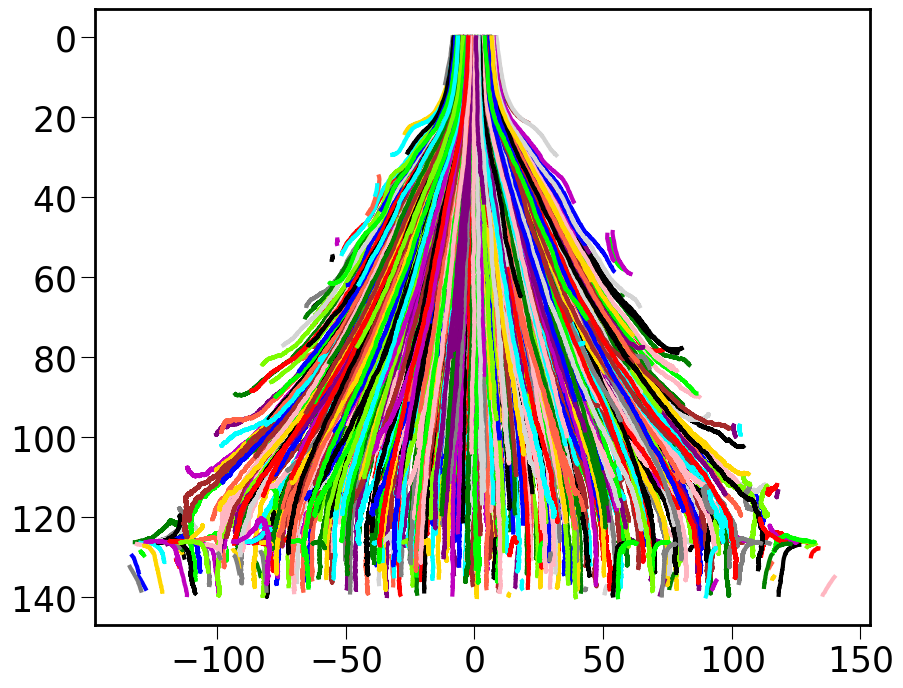

In [5]:
for evt, t in trajectories.groupby("evt"):
    plt.plot(t.x, t.z)

plt.gca().invert_yaxis()

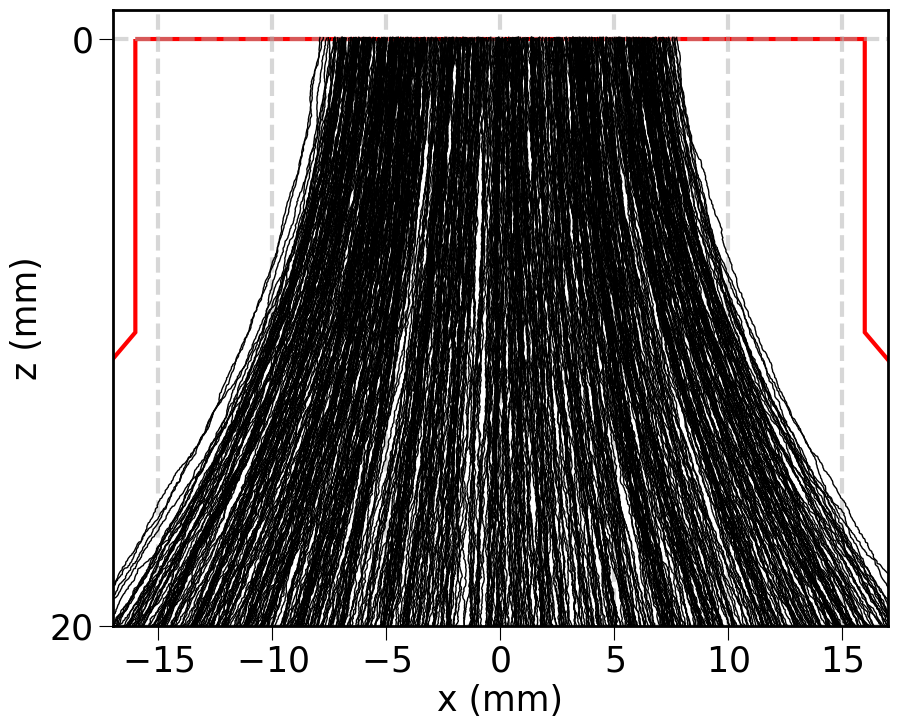

In [75]:
for evt, t in trajectories.groupby("evt"):
    plt.plot(t.x, t.z, "k-", lw=1)

points = np.array([
    [-16.,    0.],
    [-16., - 10.],
    [-136, -120.],
    [ 136, -120.],
    [ 16., - 10.],
    [ 16.,    0.],
])

ticks      = np.arange(-120, 1, 20)
ticklabels = list(map(str, -ticks))
p = Polygon(points, closed=True, facecolor="None", edgecolor="r")
plt.gca().add_patch(p)
plt.yticks(ticks, ticklabels)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.xlim(-17, 17)
plt.ylim(-20, 1)
plt.grid()

In [28]:
filename = "/home/gonzalo/data/COLINA/pCOLINA_triangular_efield_ring_degrad_4.5_form_factor_1.txt"

lines = []
for i, row in enumerate(open(filename)):
    if i<=8: continue
    row = row.strip().split(" ")
    r, z, line, _ = list(map(float, filter(bool, row)))
    if z < -0.020: continue
#    if z < -0.095: continue
#    if z > -0.090: continue
    lines.append(pd.DataFrame(dict(r=r*1e3, z=z*1e3, line=line), index=[0]))

lines = pd.concat(lines, ignore_index=True)

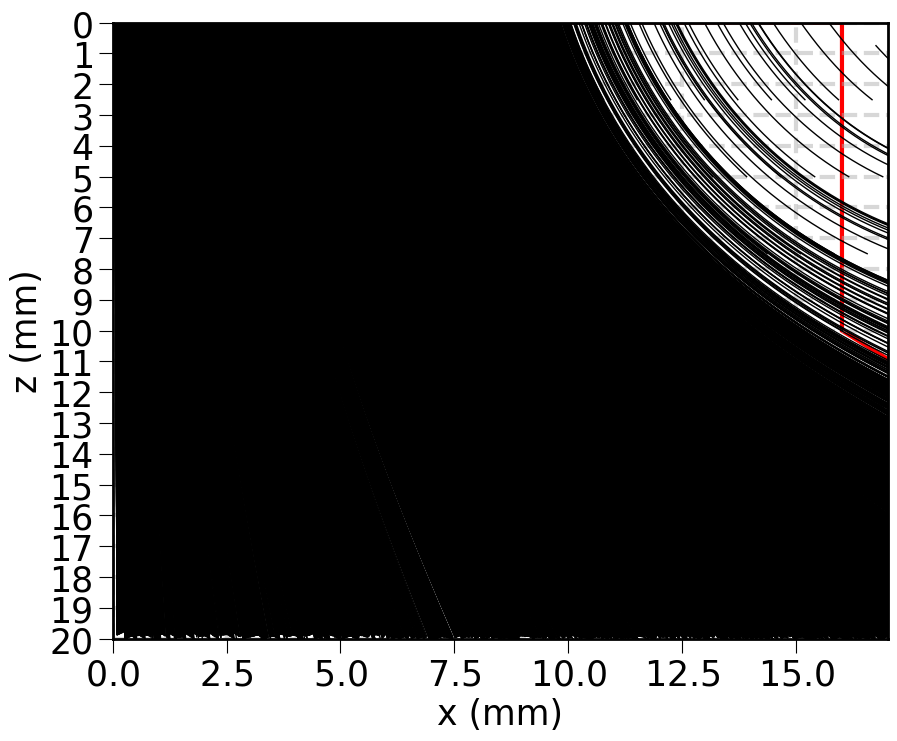

In [29]:
for evt, t in lines.groupby("line"):
    plt.plot(t.r, t.z, "k-", lw=1)

points = np.array([
    [-16.,    0.],
    [-16., - 10.],
    [-136, -120.],
    [ 136, -120.],
    [ 16., - 10.],
    [ 16.,    0.],
])

ticks      = np.arange(-120, 1, 1)
ticklabels = list(map(str, -ticks))
p = Polygon(points, closed=True, facecolor="None", edgecolor="r")
plt.gca().add_patch(p)
plt.yticks(ticks, ticklabels)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")
plt.xlim(0, 17)
plt.ylim(-20, 0)
#plt.xlim(90, 115)
#plt.ylim(-110, -80)
plt.grid()